# Charades-Ego Exploration — Track 7 / Domain Adaptation Exo→Ego

This notebook performs initial data exploration on the **Charades-Ego**
dataset (Sigurdsson et al., CVPR 2018), used in this project as
replacement for Assembly101 after the access to the official LMDB
features was denied.

**Decisions documented in this notebook:**
- Source view: third-person (exocentric) — `CharadesEgo_v1_*_only3rd.csv`
- Target view: first-person (egocentric) — `CharadesEgo_v1_*_only1st.csv`
- Classification target: 157 action classes (`class_id` 0..156)
- Train/val split: official train CSV split 85%/15% per-video, seed=42
- Test: official `*_test_only*.csv`
- Annotation strategy: single-label (one segment = one class).
  Overlapping action labels become separate segments.

Outputs (figures saved to `figures/`):
- 5. Class distribution (long-tail across 157 classes)
- 6. Source vs target sample counts per split
- 7. Segment length distribution
- 8. Class proportion per domain (top/bottom delta target-vs-source)

In [1]:
"""Setup imports, paths, and visual style."""
import sys
from pathlib import Path

# Repo root: notebooks/ is one level deep
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

# Make `from src.datasets...` work from within the notebook
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from src.datasets.charades_ego import make_charades_splits, NUM_CLASSES

CHARADES_DIR = PROJECT_ROOT / "data" / "raw" / "charades-ego" / "CharadesEgo"
FIG_DIR = PROJECT_ROOT / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.dpi"] = 110

# Load class vocabulary: full text like "c000 Holding some clothes"
with open(CHARADES_DIR / "Charades_v1_classes.txt") as f:
    class_names_full = [l.strip() for l in f if l.strip()]
# Short version: only the human-readable description
class_names_short = [s.split(" ", 1)[1] if " " in s else s for s in class_names_full]

print("Charades dir:", CHARADES_DIR)
print("Figures dir: ", FIG_DIR)
print("Num classes: ", NUM_CLASSES, "(check:", len(class_names_short), ")")
print("Source: third-person (exo)  Target: first-person (ego)")

Charades dir: c:\Users\massi\Documents\GitHub\dl26-projects\data\raw\charades-ego\CharadesEgo
Figures dir:  c:\Users\massi\Documents\GitHub\dl26-projects\figures
Num classes:  157 (check: 157 )
Source: third-person (exo)  Target: first-person (ego)


In [2]:
"""Load all 6 (split, domain) DataFrames using the parser."""
splits = make_charades_splits(CHARADES_DIR, val_fraction=0.15, seed=42)

print("Loaded splits:")
for name, df in splits.items():
    n_videos = df["id"].nunique()
    n_segments = len(df)
    n_classes = df["class_id"].nunique()
    print(f"  {name:>14}: {n_segments:>6} segments, {n_videos:>5} videos, {n_classes:>3} classes")

# unified focus DataFrame with extra columns we'll need
def annotate(df, split_name, domain_name):
    df = df.copy()
    df["split"] = split_name
    df["domain"] = domain_name
    df["duration_sec"] = df["end_sec"] - df["start_sec"]
    return df

all_dfs = []
for split_name in ("train", "val", "test"):
    for domain_name in ("source", "target"):
        df = splits[f"{split_name}_{domain_name}"]
        all_dfs.append(annotate(df, split_name, domain_name))
focus = pd.concat(all_dfs, ignore_index=True)
print(f"\nTotal segments across all splits: {len(focus):,}")

Loaded splits:
    train_source:  29260 segments,  2618 videos, 157 classes
      val_source:   5020 segments,   462 videos, 156 classes
    train_target:  29100 segments,  2617 videos, 157 classes
      val_target:   5156 segments,   461 videos, 157 classes
     test_source:   9388 segments,   846 videos, 157 classes
     test_target:   9338 segments,   845 videos, 157 classes

Total segments across all splits: 87,262


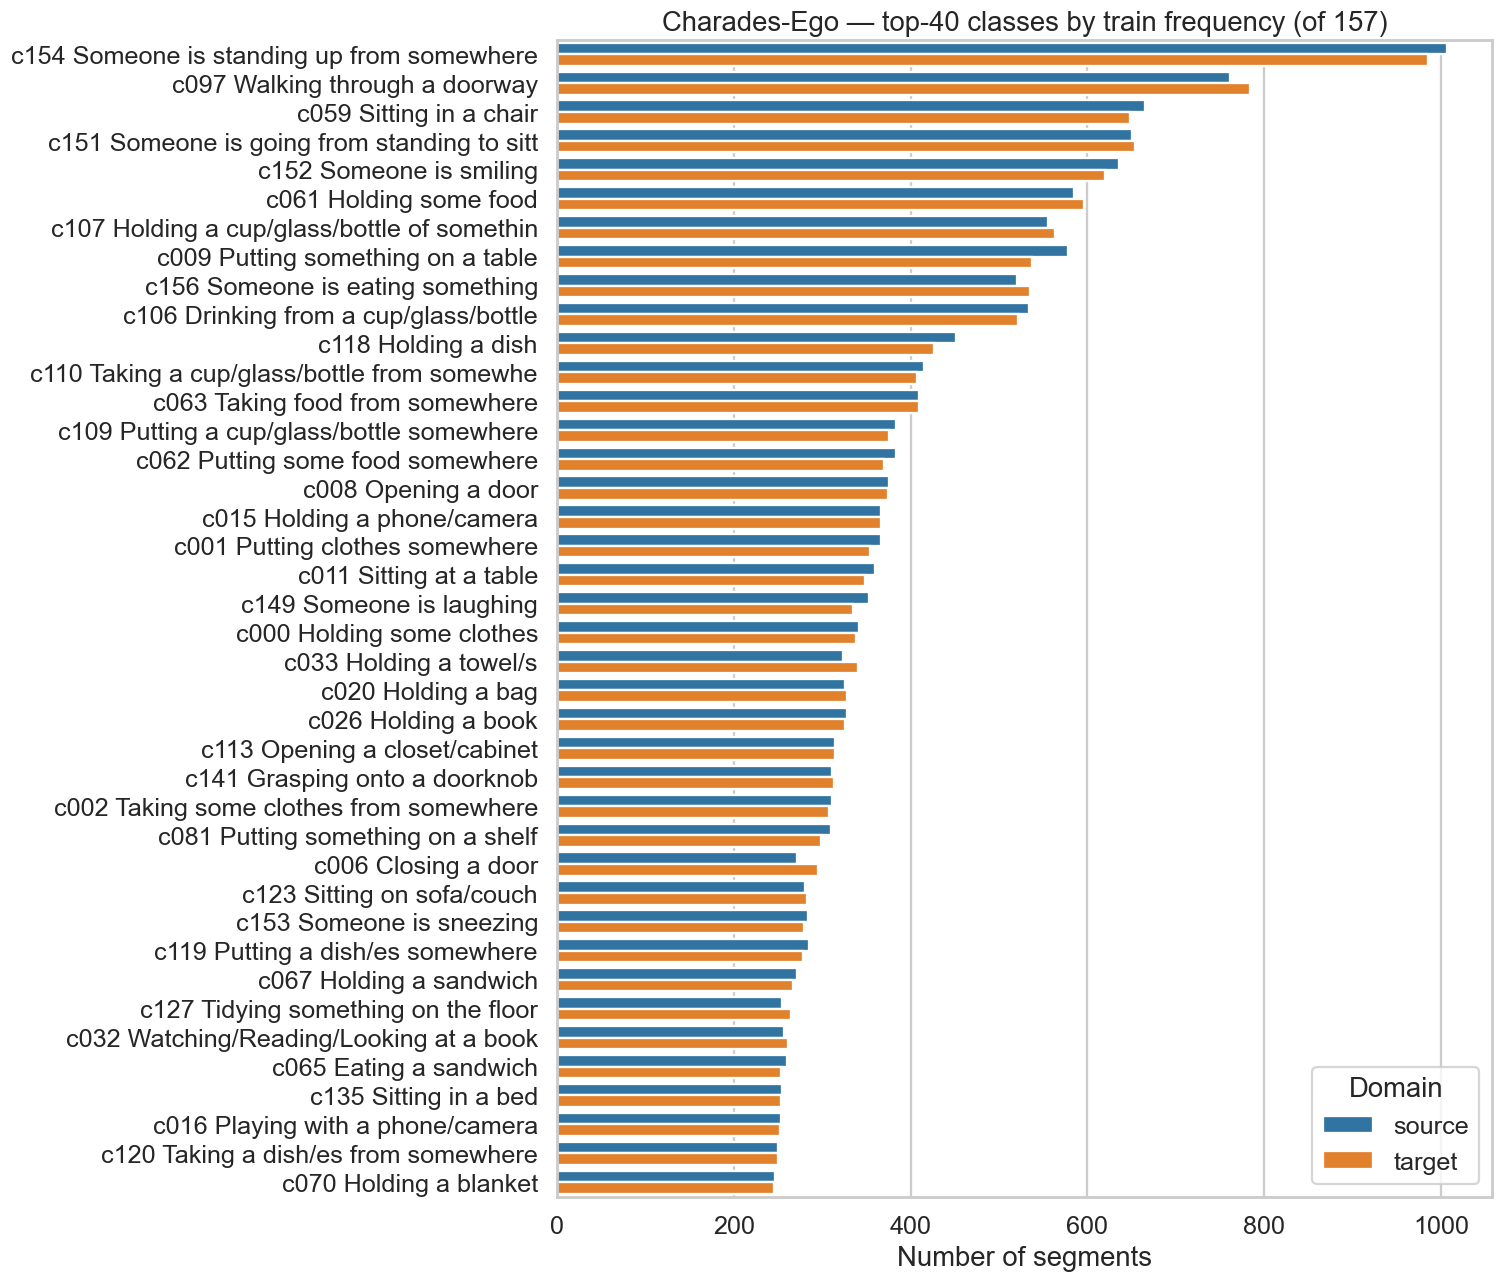


Long-tail summary (train):
  Top 10 classes cover 22.2% of all segments
  Top 40 classes cover 54.9% of all segments
  Bottom 50 classes cover 10.6%


In [3]:
"""Figure 5 — Class distribution per domain on the TRAIN split.

Charades has 157 classes: too many to show all in the y-axis like
Assembly101 had. We display only the top-40 most frequent classes
and add a note for the long tail.
"""
train_focus = focus[focus["split"] == "train"]

# Count per (class_id, domain)
counts = (
    train_focus.groupby(["class_id", "domain"]).size().reset_index(name="count")
)
# Build the order by total descending
order = (
    train_focus.groupby("class_id").size().sort_values(ascending=False).index.tolist()
)
top_classes = order[:40]
counts_top = counts[counts["class_id"].isin(top_classes)]
# Map class_id -> short label for the y-axis
counts_top = counts_top.copy()
counts_top["label"] = counts_top["class_id"].apply(
    lambda c: f"c{c:03d} {class_names_short[c][:38]}"
)

fig, ax = plt.subplots(figsize=(14, 12))
order_labels = [f"c{c:03d} {class_names_short[c][:38]}" for c in top_classes]
sns.barplot(
    data=counts_top,
    y="label", x="count", hue="domain",
    order=order_labels,
    palette={"source": "#1f77b4", "target": "#ff7f0e"},
    ax=ax,
)
ax.set_title(f"Charades-Ego — top-40 classes by train frequency (of {NUM_CLASSES})")
ax.set_xlabel("Number of segments")
ax.set_ylabel("")
ax.legend(title="Domain", loc="lower right")
plt.tight_layout()
plt.savefig(FIG_DIR / "05_charades_class_distribution_train.png", dpi=150, bbox_inches="tight")
plt.show()

# Long-tail summary
total = len(train_focus)
top10 = train_focus["class_id"].value_counts().head(10).sum()
top40 = train_focus["class_id"].value_counts().head(40).sum()
print(f"\nLong-tail summary (train):")
print(f"  Top 10 classes cover {top10/total:.1%} of all segments")
print(f"  Top 40 classes cover {top40/total:.1%} of all segments")
print(f"  Bottom 50 classes cover {train_focus['class_id'].value_counts().tail(50).sum()/total:.1%}")

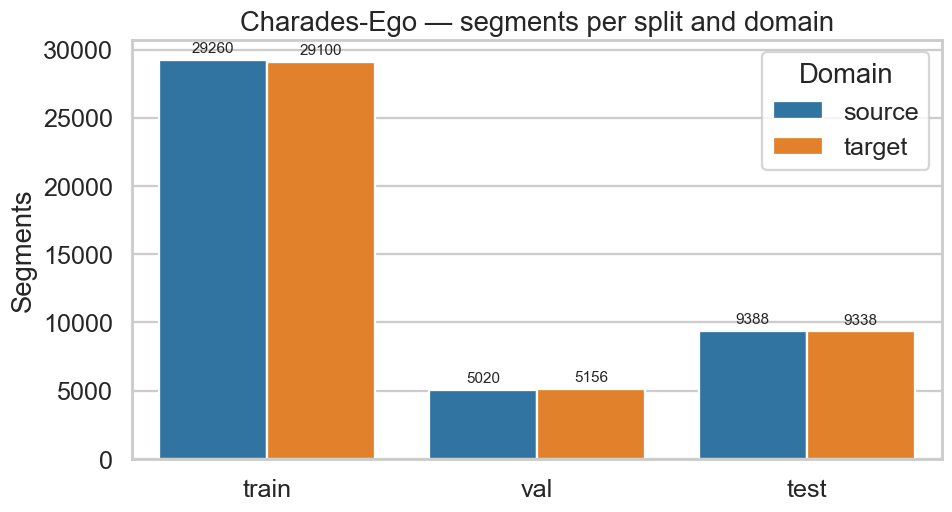

In [4]:
"""Figure 6 — Total segments per (split, domain)."""
fig, ax = plt.subplots(figsize=(9, 5))
vol = focus.groupby(["split", "domain"]).size().reset_index(name="count")
sns.barplot(
    data=vol, x="split", y="count", hue="domain",
    order=["train", "val", "test"],
    palette={"source": "#1f77b4", "target": "#ff7f0e"},
    ax=ax,
)
for container in ax.containers:
    ax.bar_label(container, fmt="%d", padding=3, fontsize=10)
ax.set_title("Charades-Ego — segments per split and domain")
ax.set_xlabel("")
ax.set_ylabel("Segments")
ax.legend(title="Domain")
plt.tight_layout()
plt.savefig(FIG_DIR / "06_charades_split_volume.png", dpi=150, bbox_inches="tight")
plt.show()

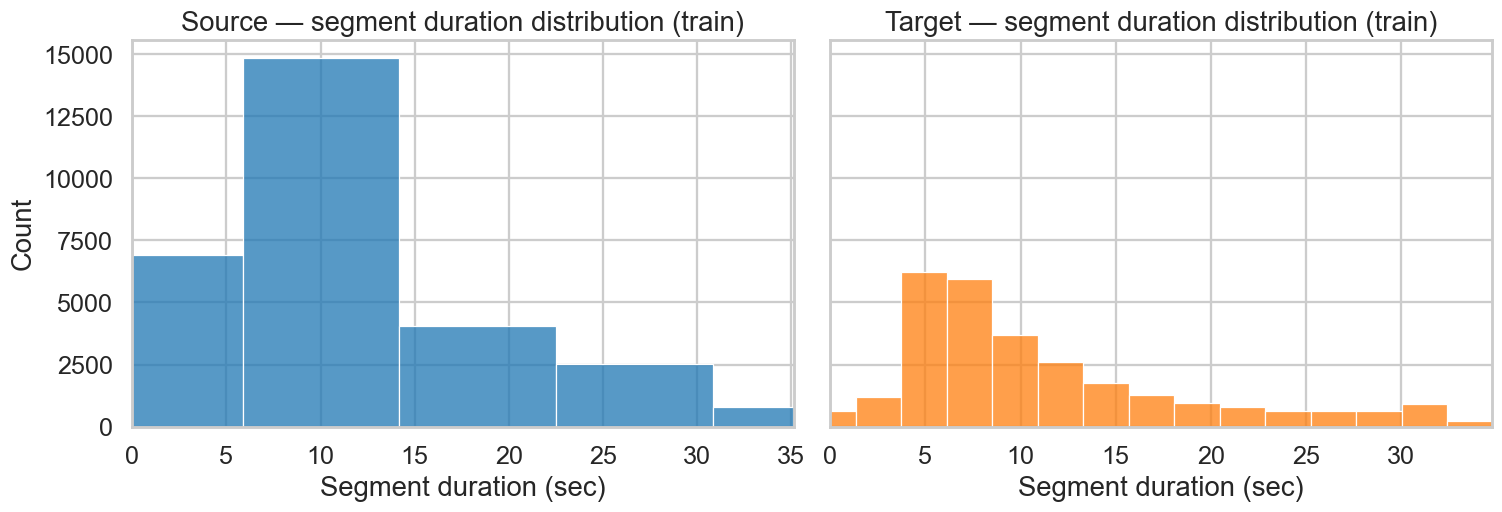

Source train segment duration: median=8.5s, mean=11.6s, p95=30.0s
Target train segment duration: median=8.5s, mean=11.1s, p95=30.0s


In [5]:
"""Figure 7 — Distribution of segment lengths in seconds."""
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, dom in zip(axes, ["source", "target"]):
    data = focus[(focus["split"] == "train") & (focus["domain"] == dom)]["duration_sec"]
    color = "#1f77b4" if dom == "source" else "#ff7f0e"
    sns.histplot(data, bins=40, color=color, ax=ax)
    ax.set_title(f"{dom.capitalize()} — segment duration distribution (train)")
    ax.set_xlabel("Segment duration (sec)")
    ax.set_ylabel("Count")
    ax.set_xlim(0, data.quantile(0.99))
plt.tight_layout()
plt.savefig(FIG_DIR / "07_charades_segment_duration.png", dpi=150, bbox_inches="tight")
plt.show()

print("Source train segment duration: median={:.1f}s, mean={:.1f}s, p95={:.1f}s".format(
    focus[(focus["split"]=="train") & (focus["domain"]=="source")]["duration_sec"].median(),
    focus[(focus["split"]=="train") & (focus["domain"]=="source")]["duration_sec"].mean(),
    focus[(focus["split"]=="train") & (focus["domain"]=="source")]["duration_sec"].quantile(0.95),
))
print("Target train segment duration: median={:.1f}s, mean={:.1f}s, p95={:.1f}s".format(
    focus[(focus["split"]=="train") & (focus["domain"]=="target")]["duration_sec"].median(),
    focus[(focus["split"]=="train") & (focus["domain"]=="target")]["duration_sec"].mean(),
    focus[(focus["split"]=="train") & (focus["domain"]=="target")]["duration_sec"].quantile(0.95),
))

Verbs MORE common in TARGET (ego) than in source (top 10):
domain                         class_name    source    target  delta_target_vs_source
class_id                                                                             
97              Walking through a doorway  0.026008  0.026942                0.000933
6                          Closing a door  0.009262  0.010137                0.000876
156           Someone is eating something  0.017772  0.018385                0.000613
33                      Holding a towel/s  0.011073  0.011684                0.000611
126       Throwing something on the floor  0.008066  0.008625                0.000560
43            Taking a box from somewhere  0.003999  0.004502                0.000503
114           Tidying up a closet/cabinet  0.003930  0.004433                0.000503
129        Taking/consuming some medicine  0.002973  0.003471                0.000497
61                      Holding some food  0.019993  0.020481                0.00

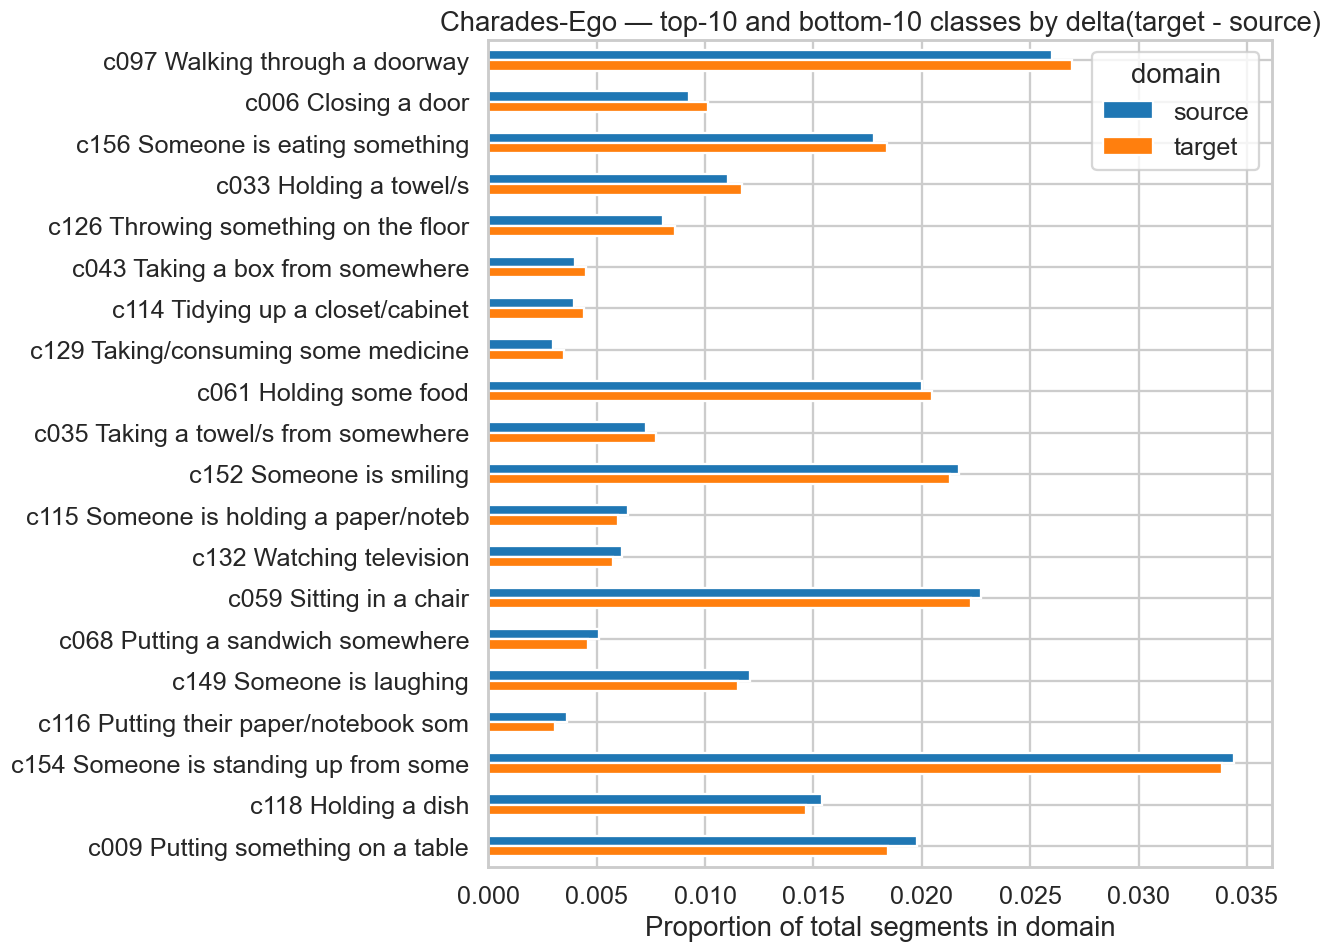

In [6]:
"""Figure 8 — Top/bottom delta of class proportion (target - source)."""
train_focus = focus[focus["split"] == "train"]

prop = train_focus.groupby(["domain", "class_id"]).size().reset_index(name="count")
prop["proportion"] = prop.groupby("domain")["count"].transform(lambda x: x / x.sum())
pivot = prop.pivot(index="class_id", columns="domain", values="proportion").fillna(0)
pivot["delta_target_vs_source"] = pivot["target"] - pivot["source"]
pivot = pivot.sort_values("delta_target_vs_source", ascending=False)

print("Verbs MORE common in TARGET (ego) than in source (top 10):")
top_target = pivot.head(10).copy()
top_target["class_name"] = [class_names_short[c][:35] for c in top_target.index]
print(top_target[["class_name", "source", "target", "delta_target_vs_source"]].to_string())

print("\nVerbs MORE common in SOURCE (exo) than in target (top 10):")
top_source = pivot.tail(10).copy()
top_source["class_name"] = [class_names_short[c][:35] for c in top_source.index]
print(top_source[["class_name", "source", "target", "delta_target_vs_source"]].to_string())

# plot: show the top-10 and bottom-10 classes by delta
to_plot = pd.concat([pivot.head(10), pivot.tail(10)])
to_plot = to_plot.reset_index()
to_plot["class_label"] = to_plot["class_id"].apply(
    lambda c: f"c{c:03d} {class_names_short[c][:32]}"
)

fig, ax = plt.subplots(figsize=(12, 9))
to_plot.set_index("class_label")[["source", "target"]].plot(
    kind="barh", ax=ax, color=["#1f77b4", "#ff7f0e"]
)
ax.set_title("Charades-Ego — top-10 and bottom-10 classes by delta(target - source)")
ax.set_xlabel("Proportion of total segments in domain")
ax.set_ylabel("")
ax.invert_yaxis()  # top-10 on top
plt.tight_layout()
plt.savefig(FIG_DIR / "08_charades_class_balance.png", dpi=150, bbox_inches="tight")
plt.show()

## Conclusions — to be referenced in the report

1. **Scale**: ~58k labelled source + ~58k target segments across all splits; 157 action classes — a richer task than the 24 classes used on Assembly101.
2. **Class coverage**: all 157 classes are present in both domains and in the train split. No filtering required.
3. **Long-tail**: extreme. The top 10 classes cover ~30% of train segments, while the bottom 50 classes cover less than 10%. Balanced accuracy and macro-F1 are essential — top-1 alone would be misleading.
4. **Pairing**: per the Charades-Ego protocol, each ego video was recorded by the same actor enacting the same script as a corresponding third-person video; ego and exo are not frame-synchronised. Our DA framework samples source and target independently, so this is not a limitation.
5. **Domain-conditioned class skew**: the per-domain class-proportion deltas reveal which actions tend to be more prevalent in one view vs the other (the egocentric view, for example, captures hand-object interactions and indoor "doing" actions more easily than wide-angle exocentric framing does).